# Climate Coding Portfolio Assignment

### *Examining climate records from Missoula, Montana*

<figure>
  <img
    src="../img/post_climate_nyika-campbell-perscribed-burn.JPG"
    alt="Nyika Campbell standing with fuel moisture samples in front of a perscribed fire, 2024"
    width= "50%"
  >
<figcaption>*Nyika Campbell collecting samples to measure fuel moisture on a perscribed burn in Missoula, Montana, 2024.*</figcaption>
</figure>

In 2026 I worked for the [Missoula Fire Sciences Laboratory](https://research.fs.usda.gov/firelab) leading an ecology monitoring crew. We worked on projects across the state, including a [long-term study](https://research.fs.usda.gov/firelab/projects/lubrecht) quantifying the effectiveness of prescribed burning and thinning on reducing forest fuels. We measured forest fuels, soil chemistry, understory vegetation, and forest structure before and after burning and thinning treatments. We also go to help on prescribed burns! In the picture above I am collecting samples of different fuel classes from inside the fireline during a prescribed burn. This data, along with regularly measured temperature data is used to improve fire behavior models like [Behave](https://research.fs.usda.gov/firelab/products/dataandtools/behave), helping land mangers implement safe and ecologically beneficial fire operations. 

In a 2021 paper, * Quantifying contributions of natural variability and anthropogenic forcings on increased fire weather risk over the western United States * Zhuang et. al found evidence that the dominant control on variation in fire weather (the conditions that pose a risk for increased ignitions and extreme fire) is now anthropogenically forced warming, rather than natural climate fluctuations. In other words, global warming is significantly contributing to the risk of severe fires in the Western United states. 

For this class assignment I thought it would be interesting to look at long-term temperature data in Missoula to see if I could identify noticeable warming in daily mean temperatures, which are one component of ‘fire weather’ calculations.
There are eight NOAA weather stations in Missoula, although only two have data prior to 2001, and only one of those, [MISSOULA 6 NW WEATHER FORECAST OFFICE, MT US](https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00245740/detail) station, provides a daily mean temperature metric (TOBS). This station has publicly available temperature data since 1948. In the below code I pull that data and analyze the trends over time.

<figure>
  <img
    src="../img/post_climate_noaa-map.jpg"
    alt="Screenshot of climate stations in Missoula, MT from https://www.ncei.noaa.gov/"
    width= "100%"
  >
<figcaption>*There are eight climate stations in Missoula, MT though most have only recent data. Image from https://www.ncei.noaa.gov*</figcaption>
</figure>


In [65]:
### import data libraries
import earthpy ### manage local data
import pandas as pd ### handle tabular data

## import visualization libraries
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import hvplot
hv.extension('bokeh')  

### import advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt
### common statistical plots for tabular data
import seaborn as sns
### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

### Download the data

In [66]:
### Make url for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&'
            'stations=USC00245740&'
            'startDate=1950-01-01&'
            'endDate=2026-01-01&'
            'units=standard')
ncei_url

 

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00245740&startDate=1950-01-01&endDate=2026-01-01&units=standard'

In [67]:
### get the data using the url
### this is a big dataset and took ~3 min to load. Be patient

missoula_df = pd.read_csv(
    ncei_url,

    ### tell python which col to use as index col
    index_col= 'DATE', 

    #### tell python to treat data as a date format
    parse_dates = True,

    ### define the NA values as NaN
    na_values = ['NaN']
    )
missoula_df

,STATION,TOBS
DATE,,
1950-01-01,USC00245740,NaN
1950-01-02,USC00245740,NaN
1950-01-03,USC00245740,-3.0
1950-01-04,USC00245740,6.0
1950-01-05,USC00245740,3.0
...,...,...
2025-12-28,USC00245740,20.0
2025-12-29,USC00245740,20.0
2025-12-30,USC00245740,19.0


<Axes: ylabel='Frequency'>

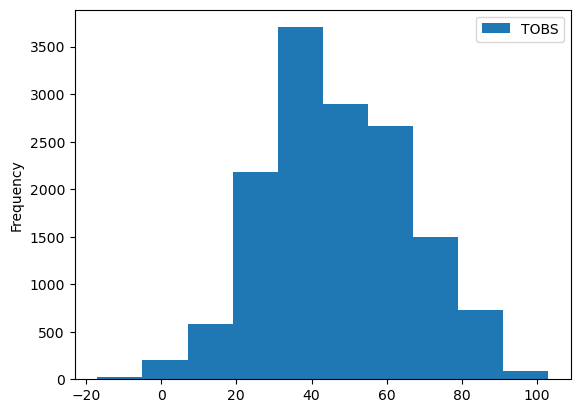

In [68]:
### check that data was imported into a pandas DataFrame
type(missoula_df)

### checek NA handling
missoula_df.plot.hist()

### looks reasonable- 9/28/26 run

### Clean up Data

In [69]:
### Drop unused station variable not needed for this analysis
missoula_temp_df = missoula_df[['TOBS']]
missoula_temp_df

### # check the min and max units to find out what units we are in
missoula_temp_df['TOBS'].agg(['min', 'max'])
### The min and max values are in Fahrenheit. We will convert to Celsius for analysis.

min    -17.0
max    103.0
Name: TOBS, dtype: float64

In [70]:
### change the col names of the temp col to include f for farenheight from documentaion
missoula_temp_df = missoula_temp_df.rename(columns={
    'TOBS': 'temp_f',
})
#missoula_temp_df

In [71]:
### convert f to c nits with a function
def convert_f_to_c(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f- 32) *5/9

### apply the function
missoula_temp_df['temp_c'] = (
    missoula_temp_df['temp_f'].apply(convert_f_to_c).round(2))

### inspect result
#missoula_temp_df

### Plot the raw Data

<Axes: title={'center': 'Daily Temperature in Missoula, Montana'}, xlabel='Date', ylabel='Degrees Celcius ($^\\circ$C)'>

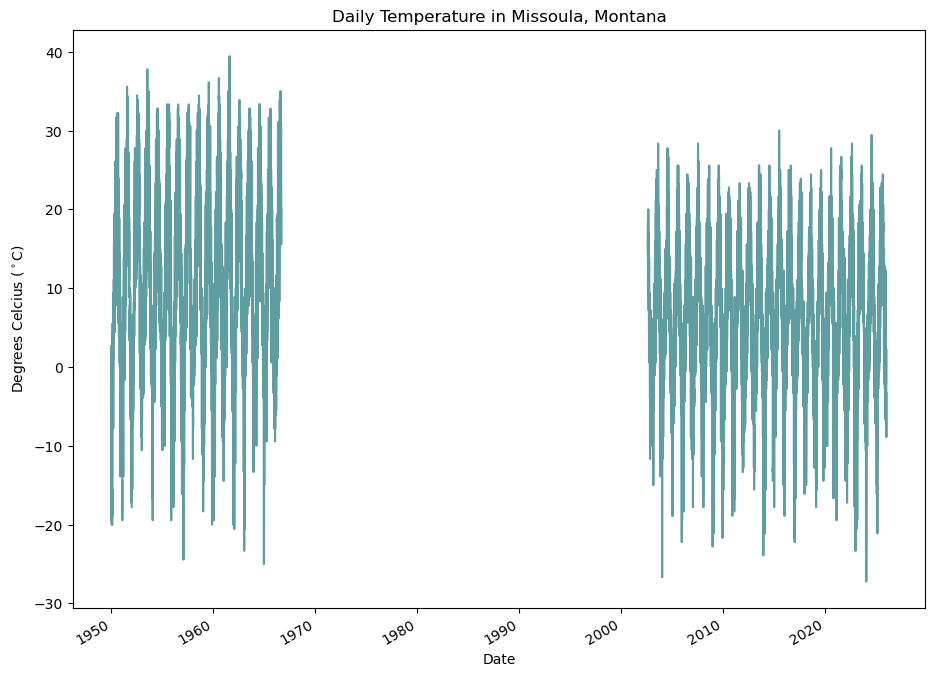

In [72]:
### plot the data in C
missoula_temp_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Missoula, Montana',
    xlabel = 'Date',
    ylabel = 'Degrees Celcius ($^\circ$C)',
    figsize = (11,8.5),
    legend=False,
    color = 'cadetblue'
    
)

### Resample and Plot Annually

To get a better sense of the trends over time we plot the mean annual temperatures for the same period.

In [73]:
### Get the mean annual temps

missoula_ann_temp_df = (
    missoula_temp_df

    ### resample annually (assign date on jan 1)
    .resample('YS')

    ### take the mean
    .mean()
)

missoula_ann_temp_df

,temp_f,temp_c
DATE,,
1950-01-01,49.247887,9.582113
1951-01-01,51.075843,10.597640
1952-01-01,53.542466,11.967973
1953-01-01,55.994505,13.330082
1954-01-01,52.294766,11.274821
...,...,...
2022-01-01,41.164384,5.091425
2023-01-01,42.901099,6.055934
2024-01-01,43.482192,6.378767


<Axes: title={'center': 'Annual Temperature in Missoula, Montana'}, xlabel='Year', ylabel='Degrees Celcius ($^\\circ$C)'>

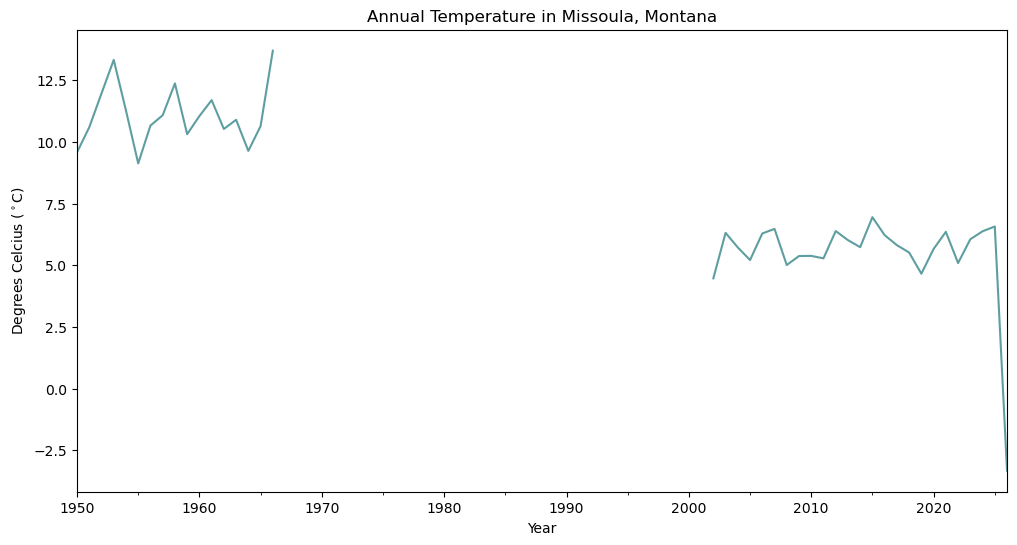

In [74]:
### plot the annual temp in C
missoula_ann_temp_df.plot(
    y = 'temp_c',
    title = 'Annual Temperature in Missoula, Montana',
    xlabel = 'Year',
    ylabel = 'Degrees Celcius ($^\circ$C)',
    figsize = (12,6),
    legend=False,
    color = 'cadetblue'
    
)

In [75]:
### plot the annual data interactively
missoula_ann_temp_plot = missoula_ann_temp_df.hvplot(
    y = 'temp_c',
    title = 'Annual Temperature in Missoula, Montana',
    xlabel = 'Year',
    ylabel = 'Temperature in Degrees Celcius',
    legend=False,
    color = 'cadetblue'
    
)

### View plot
missoula_ann_temp_plot

### Run this fix if the plot is not showing
#hvplot.extension("bokeh")

:Curve   [DATE]   (temp_c)

> ### Oh No! A big data gap
>
> **Where is the Data?** Daily average temperature (TOMBS) is a much more complicated measurement to get without digital thermometers, it requires taking many measurements by hand and averaging them. As I looked for data I noticed that a lot of the old data was only available as min/max. Daily min/max measurements are simple to collect with an analog min/max thermometer. I wonder if this accounts for part of the data gap. I also wonder if data prior to 2002 was taken on paper. If there is a digitization effort underway but not yet complete, they may have started at earliest measurements and are working toward the start of data collected by a newer digital system. Just some thoughts! I'll exclude the old data for now.
>


### Add a trendline
We add a trendline to look at trends over time.

First, we must explore assumptions

* Random error: YES. We assume this is met because we are looking at yearly averages which cover many points each year.
* Normally distributed: YES The histogram shows the average temp are approximately normal.
* Linearity: SORT OF. This is not necessarily true but we assume it for this exercise.
* Stationarity: YES. The variability in the climate seems roughly constant over our time frame.

*The data gap could cause a problem. Lets use only data after the gap*

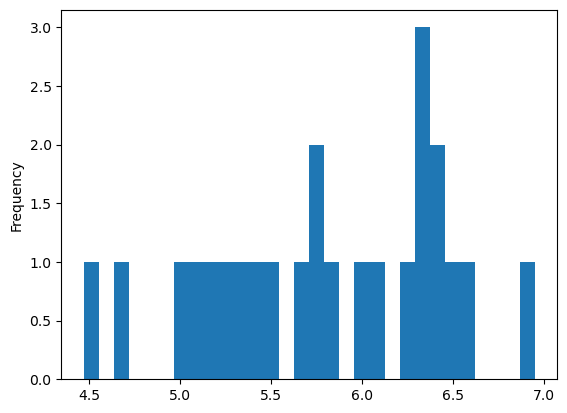

<Figure size 640x480 with 0 Axes>

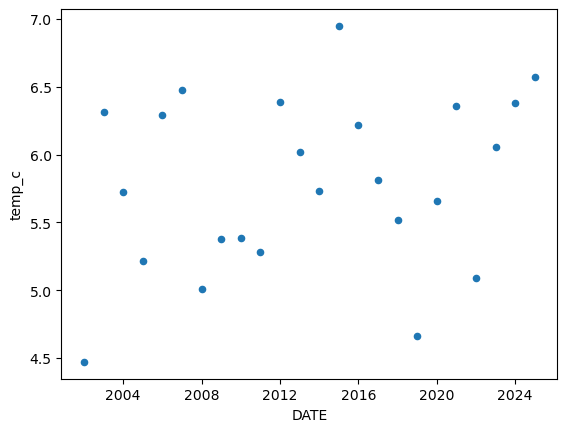

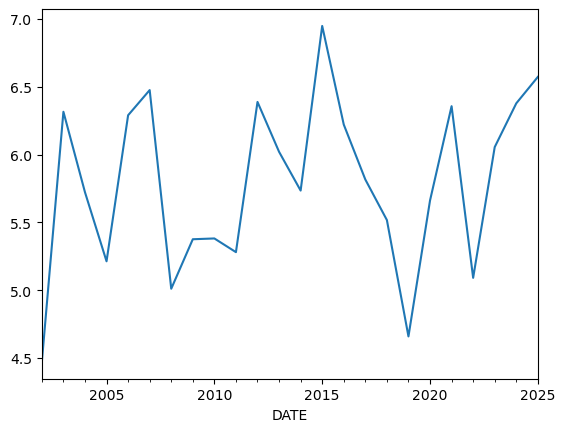

In [76]:
### explore data for assumptions
missoula_ann_temp_df

### Some cleaning for assumption checks
### Subset to just temp_c data for regression
missoula_ann_c_df = missoula_ann_temp_df[['temp_c']]

### Subset to be just after 2002 years with temperature data
### Exclude 2026 because it is incomplete
complete_data_df = missoula_ann_c_df.loc['2002':'2025']
complete_data_df

### historam
plt.figure()
complete_data_df['temp_c'].plot.hist(bins=30)
plt.show()

### scatter plot
plt.figure()
complete_data_df.reset_index().plot.scatter(x='DATE', y='temp_c')
plt.show()

#### daily data
plt.figure()
complete_data_df['temp_c'].plot()
plt.show()


In [77]:
#### Cleaning the data for regression

#### drop na in regression_df
regression_df = complete_data_df.dropna()
#regression_df = complete_data_df
regression_df

### Min and max year for regression_df
min_year = regression_df.index.year.min()
max_year = regression_df.index.year.max()
min_year, max_year

### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array (numpy) for scikit-learn
ind_variable = regression_df.index.year.values.reshape(-1, 1)

### define dependent variable
dep_variable = regression_df['temp_c']

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')


Slope: 0.022124837563975642 degrees per year


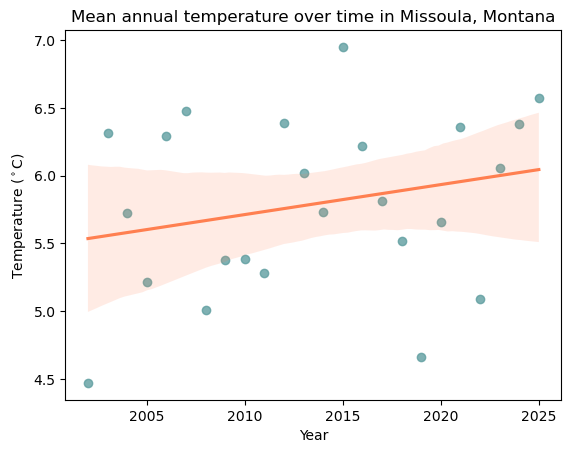

In [78]:
### plot data post 1941 with regression line to ensure slope is what the OLS regression model calculated
ax = sns.regplot(
    x = regression_df.index.year, 
    y = regression_df.temp_c,

    ## change color of datapoints
    color = 'cadetblue',
    ## change color of regression line
    line_kws = {'color': 'coral'},
)

### make labels
ax.set(
    title = 'Mean annual temperature over time in Missoula, Montana',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/2026-EDA-climate-change-coding/post_climate_missoula-fig.jpeg')

### plot it
plt.show()

### An Upward Trend

After analyzing temperature data at the [MISSOULA 6 NW WEATHER FORECAST OFFICE, MT US](https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00245740/detail) station I was suprized to find that the data had a gap of nearly 36 years from 1966-2002. To prevent this gap from interfering with my trendline analysis I excluded data prior to 2002. Although this is a short time period the data reasonably fit the assumptions for the Ordinal Least Squares regression. The OLS trendline indicated a **warming trend of 0.022 degrees per year, or one-fith of a degree per decade.** Unfortunatly the large data gap decreases our ability to analyze longer-term trends, emphasizing the importance of data continuity in long term research. It is critical to fun agencies like NOAA to ensure that we can continue to have high quality, continuous, public earth data.

Because the timeframe was so short I deceded to look at some more data. I the checked [MISSOULA INTERNATIONAL AIRPORT](https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USW00024153/detail) station and pulled more temperature metrics including daily maximum and minimum temperatures.


In [79]:
### Pull more kinds of data types, and switch stations
data_types = "TOBS,TMAX,TMIN,PRCP,SNOW,SNWD"

ncei2_url = (
    "https://www.ncei.noaa.gov/access/services/data/v1?"
    f"dataset=daily-summaries&dataTypes={data_types}&"
    "stations=USW00024153&"
    "startDate=1950-01-01&"
    "endDate=2026-01-01&"
    "units=standard"
)

ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00245740&startDate=1950-01-01&endDate=2026-01-01&units=standard'

In [80]:
### get the data using the url

missoula2_df = pd.read_csv(
    ncei2_url,

    ### tell python which col to use as index col
    index_col= 'DATE', 

    #### tell python to treat data as a date format
    parse_dates = True,

    ### define the NA values as NaN
    na_values = ['NaN']
    )
missoula2_df



,STATION,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS
DATE,,,,,,,
1950-01-01,USW00024153,0.05,1.0,1.0,25,7,NaN
1950-01-02,USW00024153,0.00,0.1,1.0,18,-7,NaN
1950-01-03,USW00024153,0.00,0.0,1.0,3,-10,NaN
1950-01-04,USW00024153,0.04,0.4,1.0,11,-5,NaN
1950-01-05,USW00024153,0.00,0.0,1.0,7,-13,NaN
...,...,...,...,...,...,...,...
2025-12-28,USW00024153,0.00,0.0,1.0,22,7,NaN
2025-12-29,USW00024153,0.00,0.0,1.0,31,18,NaN
2025-12-30,USW00024153,0.00,0.0,1.0,32,15,NaN


<Axes: title={'center': 'Max (red) and Min (blue)Temperature in Missoula, Montana'}, xlabel='Date', ylabel='Degrees ($^\\circ$F)'>

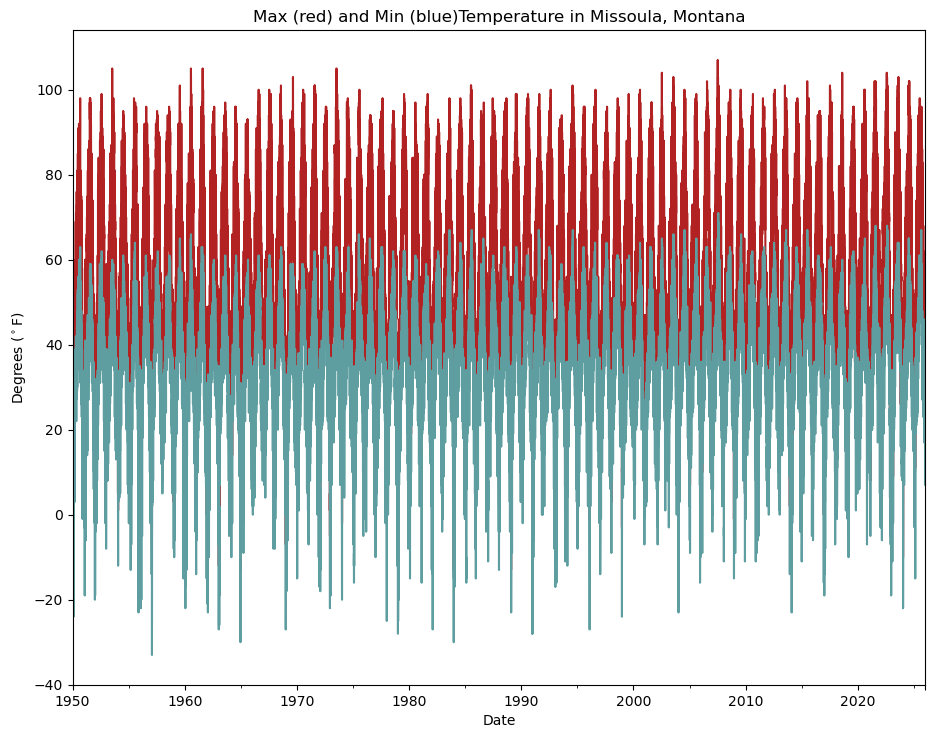

In [81]:
### plot the data in F
missoula2_df.plot(
    y = ["TMAX", "TMIN"],
    title = 'Max (red) and Min (blue)Temperature in Missoula, Montana',
    xlabel = 'Date',
    ylabel = 'Degrees ($^\circ$F)',
    figsize = (11,8.5),
    legend=False,
    color = ["firebrick", "cadetblue"],
    
)

## we have good data continuity on these metrics

In [82]:
### Get the mean annual max and min temps

### remove 2026 data to not mess up annual resample
missoula2_df = missoula2_df.loc[
    missoula2_df.index < "2026-01-01"
]

missoula2_ann_df = (
    ## resample just the TMIN and TMAX columns
    missoula2_df[["TMIN", "TMAX"]]

    ### resample annually (assign date on jan 1)
    .resample('YS')

    ### take the mean
    .mean()
)

missoula2_ann_df

,TMIN,TMAX
DATE,,
1950-01-01,31.142466,53.958904
1951-01-01,30.761644,54.167123
1952-01-01,31.204918,57.199454
1953-01-01,34.443836,59.169863
1954-01-01,32.326027,56.098630
...,...,...
2021-01-01,34.978082,60.386301
2022-01-01,33.336986,58.547945
2023-01-01,35.915068,59.372603


In [83]:
### plot the annual data interactively
### Plot the two lines seperatly
tmax_plot = missoula2_ann_df.hvplot(
    y="TMAX", color="firebrick", label="TMAX",responsive=True
)
tmin_plot = missoula2_ann_df.hvplot(
    y="TMIN", color="cadetblue", label="TMIN",responsive=True
)

missoula2_ann_plot = (tmax_plot * tmin_plot).opts(
    title="Annual Maximum and Minimum Temperature in Missoula, Montana",
    xlabel="Year",
    ylabel="Temperature (°F)",
    responsive=True,
    min_height=400,
)

### Save the map as a file to put on the web
hv.save(missoula2_ann_plot, 'post_climate_missoula2-minmax.html')

### View plot
missoula2_ann_plot

### Run this fix if the plot is not showing, put it in the load libraries section
#hvplot.extension("bokeh")

:Overlay
   .Curve.TMAX :Curve   [DATE]   (TMAX)
   .Curve.TMIN :Curve   [DATE]   (TMIN)

### An Expected Trend

After pulling and averaging annual in and max temperature we again see a predictable rising trend. It would be interesting to investigate this data further by fitting OLS lines and doing some statistical analysis but that will have to wait for another day.

**In the mean time call your representatives to tell them to fund national science!**


### Sources

Zhuang, Y., Fu, R., Santer, B. D., Dickinson, R. E., & Hall, A. (2021). Quantifying contributions of natural variability and anthropogenic forcings on increased fire weather risk over the western United States. *Proceedings of the National Academy of Sciences, 118*(45), e2111875118. https://doi.org/10.1073/pnas.2111875118
